# Horn of Africa Rainfall Seasonality

Seasonal cycle of hourly precipitation from ICON and IFS-FESOM
destinE climate projections for 2020 over the Horn of Africa.

**Requires**:
- Polytope auth (see `docs/polytope_setup.md`)
- Conda env `destine` (see `requirements.txt`)

In [1]:
import sys, os
_here = os.getcwd()
if "../get-data" not in sys.path:
    sys.path.insert(0, "../get-data")

import logging, warnings
import earthkit.data
import earthkit.plots
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from polytope_zarr import PolytopeZarrStore

## 1. Fetch data

In [32]:
imerg = xr.open_mfdataset(
    "../../acclimatise/get-data/imerg_africa/yearly_nc/pr_imerg_v07_africa_daily_200*.nc"
    ).sel(lat=slice(5, 10), lon=slice(44, 49)).mean(dim=["lat", "lon"], skipna=True).groupby("time.dayofyear").mean("time")

icon = xr.open_mfdataset(
    "../data/horn_of_africa/ICON/*.nc"
    ).mean(dim=["points"], skipna=True).groupby("time.dayofyear").mean("time")
icon["avg_tprate"] = icon.avg_tprate * 86400

ifs = xr.open_mfdataset(
    "../data/horn_of_africa/IFS-FESOM/*.nc"
    ).mean(dim=["points"], skipna=True).groupby("time.dayofyear").mean("time")
ifs["avg_tprate"] = ifs.avg_tprate * 86400

In [34]:
imerg

<xarray.Dataset> Size: 4kB
Dimensions:    (dayofyear: 366)
Coordinates:
  * dayofyear  (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 361 362 363 364 365 366
Data variables:
    pr         (dayofyear) float32 1kB dask.array<chunksize=(1,), meta=np.ndarray>
Attributes: (12/14)
    BeginDate:       2000-01-01
    BeginTime:       00:00:00.000Z
    EndDate:         2000-01-01
    EndTime:         23:59:59.999Z
    FileHeader:      StartGranuleDateTime=2000-01-01T00:00:00.000Z;\nStopGran...
    InputPointer:    3B-HHR.MS.MRG.3IMERG.20000101-S000000-E002959.0000.V07B....
    ...              ...
    ProductionTime:  2024-11-14T14:54:09.574Z
    history:         Created 2026-07-15T13:34:07Z by download_imerg_v07_afric...
    region_lat_min:  -10.0
    region_lat_max:  25.0
    region_lon_min:  -20.0
    region_lon_max:  55.0

In [35]:
imerg.rolling(dayofyear=3, center=True).mean()

<xarray.Dataset> Size: 4kB
Dimensions:    (dayofyear: 366)
Coordinates:
  * dayofyear  (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 361 362 363 364 365 366
Data variables:
    pr         (dayofyear) float32 1kB dask.array<chunksize=(3,), meta=np.ndarray>
Attributes: (12/14)
    BeginDate:       2000-01-01
    BeginTime:       00:00:00.000Z
    EndDate:         2000-01-01
    EndTime:         23:59:59.999Z
    FileHeader:      StartGranuleDateTime=2000-01-01T00:00:00.000Z;\nStopGran...
    InputPointer:    3B-HHR.MS.MRG.3IMERG.20000101-S000000-E002959.0000.V07B....
    ...              ...
    ProductionTime:  2024-11-14T14:54:09.574Z
    history:         Created 2026-07-15T13:34:07Z by download_imerg_v07_afric...
    region_lat_min:  -10.0
    region_lat_max:  25.0
    region_lon_min:  -20.0
    region_lon_max:  55.0

## 3. Load IMERG

## 2. Plot seasonal cycle

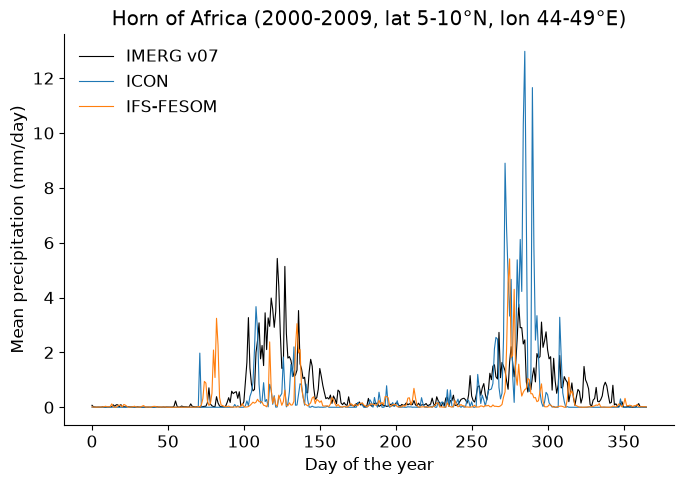

In [36]:
fsize = 12
plt.rcParams["font.size"] = fsize
fig, ax = plt.subplots(1, 1, figsize = (7, 5), layout = "tight")

ax.plot(imerg.pr, label="IMERG v07", color="black", lw=.8)
ax.plot(icon.avg_tprate, label="ICON", lw=.8)
ax.plot(ifs.avg_tprate, label="IFS-FESOM", lw=.8)

ax.set_xlabel("Day of the year")
ax.set_ylabel("Mean precipitation (mm/day)")
ax.set_title("Horn of Africa (2000-2009, lat 5-10°N, lon 44-49°E)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(edgecolor="white")
plt.savefig("plots/seasonality_hornofafrica_daily.png", dpi=300)

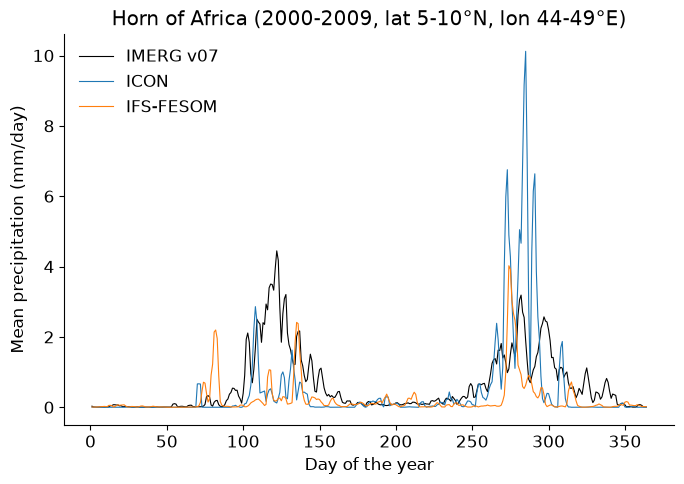

In [37]:
fsize = 12
plt.rcParams["font.size"] = fsize
fig, ax = plt.subplots(1, 1, figsize = (7, 5), layout = "tight")

ax.plot(imerg.pr.rolling(dayofyear=3, center=True).mean(), label="IMERG v07", color="black", lw=.8)
ax.plot(icon.avg_tprate.rolling(dayofyear=3, center=True).mean(), label="ICON", lw=.8)
ax.plot(ifs.avg_tprate.rolling(dayofyear=3, center=True).mean(), label="IFS-FESOM", lw=.8)

ax.set_xlabel("Day of the year")
ax.set_ylabel("Mean precipitation (mm/day)")
ax.set_title("Horn of Africa (2000-2009, lat 5-10°N, lon 44-49°E)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(edgecolor="white")
plt.savefig("plots/seasonality_hornofafrica_daily_rw3.png", dpi=300)